# BloomNext: Early-Prediction of Harmful Algal Blooms
**CS 4262 - Foundations of Machine Learning, Vanderbilt University**

Trevor Xing-Xie, Nirmay Bhanderi, Connor Brugger

---

## 0. Setup

In [2]:
!pip install pandas numpy matplotlib scikit-learn seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, PrecisionRecallDisplay,
    make_scorer, mean_absolute_error, mean_squared_error
)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## 1. Load and Clean HABSOS Data

Data downloaded from NCEI (https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.nodc:0120767).  
Place `habsos_20240430.csv` in the same directory as this notebook.

In [4]:
HABSOS_FILE = "habsos_20240430.csv"

raw = pd.read_csv(HABSOS_FILE)
print(f"Raw shape: {raw.shape}")
print(f"Columns: {list(raw.columns)}")
raw.head()

Raw shape: (211834, 28)
Columns: ['STATE_ID', 'DESCRIPTION', 'Unnamed: 2', 'LATITUDE', 'LONGITUDE', 'SAMPLE_DATE', 'SAMPLE_TIME', 'SAMPLE_DEPTH', 'GENUS', 'SPECIES', 'CATEGORY', 'CELLCOUNT', 'CELLCOUNT_UNIT', 'CELLCOUNT_QA', 'SALINITY', 'SALINITY_UNIT', 'SALINITY_QA', 'WATER_TEMP', 'WATER_TEMP_UNIT', 'WATER_TEMP_QA', 'WIND_DIR', 'WIND_DIR_UNIT', 'WIND_DIR_QA', 'WIND_SPEED', 'WIND_SPEED_UNIT', 'WIND_SPEED_QA', 'OBJECTID', 'Unnamed: 27']


,STATE_ID,DESCRIPTION,Unnamed: 2,LATITUDE,LONGITUDE,SAMPLE_DATE,SAMPLE_TIME,SAMPLE_DEPTH,GENUS,SPECIES,...,WATER_TEMP_UNIT,WATER_TEMP_QA,WIND_DIR,WIND_DIR_UNIT,WIND_DIR_QA,WIND_SPEED,WIND_SPEED_UNIT,WIND_SPEED_QA,OBJECTID,Unnamed: 27
0,TX,Copano Bay 4,NaN,28.07237,-97.21968,2023/09/27,7:14,NaN,Karenia,brevis,...,NaN,9,NaN,NaN,9,NaN,NaN,9,2134075,NaN
1,TX,Copano Bay 2,NaN,27.99567,-97.16831,2023/09/27,8:21,NaN,Karenia,brevis,...,NaN,9,NaN,NaN,9,NaN,NaN,9,2134077,NaN
2,TX,Copano Bay 3,NaN,28.03930,-97.15836,2023/09/27,7:45,NaN,Karenia,brevis,...,NaN,9,NaN,NaN,9,NaN,NaN,9,2134076,NaN
3,TX,Copano Bay 1,NaN,28.06491,-97.11270,2023/09/27,9:07,NaN,Karenia,brevis,...,NaN,9,NaN,NaN,9,NaN,NaN,9,2134078,NaN
4,FL,off New Smyrna Beach; Atlantic,NaN,29.17460,-78.27890,1990/12/20,NaN,0.5,Karenia,brevis,...,deg. C,1,NaN,NaN,9,NaN,NaN,9,1590299,NaN


In [5]:
# NCEI HABSOS columns:
# STATE_ID, DESCRIPTION (location name), empty col, LATITUDE, LONGITUDE,
# SAMPLE_DATE, SAMPLE_TIME, SAMPLE_DEPTH, GENUS, SPECIES, CATEGORY,
# CELLCOUNT, CELLCOUNT_UNIT, ..., WATER_TEMP, ...

# drop unnamed empty columns
raw = raw.loc[:, ~raw.columns.str.startswith('Unnamed')]
raw.columns = raw.columns.str.strip().str.upper()
print("Columns after cleanup:", list(raw.columns))

# rename to standard names
df = raw.rename(columns={
    'SAMPLE_DATE': 'date',
    'LATITUDE': 'latitude',
    'LONGITUDE': 'longitude',
    'CELLCOUNT': 'cellcount',
    'STATE_ID': 'state',
    'DESCRIPTION': 'location',
    'GENUS': 'genus',
    'SPECIES': 'species',
    'CATEGORY': 'category',
    'WATER_TEMP': 'water_temp'
})

print(f"\nTotal rows: {len(df)}")
print(f"States: {df['state'].unique()}")

# filter for Florida
df = df[df['state'] == 'FL']
print(f"After FL filter: {len(df)} rows")

# filter for Karenia brevis (genus=Karenia, species=brevis)
print(f"Genera present: {df['genus'].unique()[:10]}")
df = df[df['genus'].str.lower().str.strip() == 'karenia']
print(f"After Karenia filter: {len(df)} rows")

print(f"\nFiltered shape: {df.shape}")
df.head()

Columns after cleanup: ['STATE_ID', 'DESCRIPTION', 'LATITUDE', 'LONGITUDE', 'SAMPLE_DATE', 'SAMPLE_TIME', 'SAMPLE_DEPTH', 'GENUS', 'SPECIES', 'CATEGORY', 'CELLCOUNT', 'CELLCOUNT_UNIT', 'CELLCOUNT_QA', 'SALINITY', 'SALINITY_UNIT', 'SALINITY_QA', 'WATER_TEMP', 'WATER_TEMP_UNIT', 'WATER_TEMP_QA', 'WIND_DIR', 'WIND_DIR_UNIT', 'WIND_DIR_QA', 'WIND_SPEED', 'WIND_SPEED_UNIT', 'WIND_SPEED_QA', 'OBJECTID']

Total rows: 211834
States: ['TX' 'FL' 'AL' 'MS']
After FL filter: 205168 rows
Genera present: ['Karenia']
After Karenia filter: 205168 rows

Filtered shape: (205168, 26)


,state,location,latitude,longitude,date,SAMPLE_TIME,SAMPLE_DEPTH,genus,species,category,...,water_temp,WATER_TEMP_UNIT,WATER_TEMP_QA,WIND_DIR,WIND_DIR_UNIT,WIND_DIR_QA,WIND_SPEED,WIND_SPEED_UNIT,WIND_SPEED_QA,OBJECTID
4,FL,off New Smyrna Beach; Atlantic,29.1746,-78.2789,1990/12/20,NaN,0.5,Karenia,brevis,not observed,...,24.2,deg. C,1,NaN,NaN,9,NaN,NaN,9,1590299
5,FL,off Daytona Beach; Atlantic,28.9822,-78.3590,1990/12/20,NaN,0.5,Karenia,brevis,very low,...,25.9,deg. C,1,NaN,NaN,9,NaN,NaN,9,1590298
6,FL,off Daytona Beach; Atlantic,29.0000,-78.4700,1991/08/19,10:52,0.5,Karenia,brevis,not observed,...,30.0,deg. C,1,NaN,NaN,9,NaN,NaN,9,1644042
7,FL,off Cape Canaveral; Atlantic,28.5350,-78.5570,1990/12/20,NaN,0.5,Karenia,brevis,very low,...,24.0,deg. C,1,NaN,NaN,9,NaN,NaN,9,1590297
8,FL,off Cape Canaveral; Atlantic,28.1060,-78.8310,1990/12/21,NaN,0.5,Karenia,brevis,not observed,...,24.9,deg. C,1,NaN,NaN,9,NaN,NaN,9,1590306


In [6]:
df['date'] = pd.to_datetime(df['date'], format='%Y/%m/%d', errors='coerce')
df['cellcount'] = pd.to_numeric(df['cellcount'], errors='coerce')
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df['water_temp'] = pd.to_numeric(df['water_temp'], errors='coerce')

before = len(df)
df = df.dropna(subset=['date', 'latitude', 'longitude', 'cellcount'])
df = df[df['cellcount'] >= 0].copy()
print(f"Dropped {before - len(df)} rows with missing/invalid values")

print(f"Cleaned shape: {df.shape}")
print(f"Date range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"Cell count range: {df['cellcount'].min():.0f} to {df['cellcount'].max():.0f}")
print(f"Cell count median: {df['cellcount'].median():.0f}")
print(f"Water temp available: {df['water_temp'].notna().sum()} / {len(df)} ({100*df['water_temp'].notna().mean():.1f}%)")
print(f"Unique years: {sorted(df['date'].dt.year.unique())}")

Dropped 0 rows with missing/invalid values
Cleaned shape: (205168, 26)
Date range: 1953-08-19 to 2024-03-25
Cell count range: 0 to 388400000
Cell count median: 0
Water temp available: 102272 / 205168 (49.8%)
Unique years: [np.int32(1953), np.int32(1954), np.int32(1955), np.int32(1956), np.int32(1957), np.int32(1958), np.int32(1959), np.int32(1960), np.int32(1961), np.int32(1962), np.int32(1963), np.int32(1964), np.int32(1965), np.int32(1966), np.int32(1967), np.int32(1968), np.int32(1969), np.int32(1970), np.int32(1971), np.int32(1972), np.int32(1973), np.int32(1974), np.int32(1975), np.int32(1976), np.int32(1977), np.int32(1978), np.int32(1979), np.int32(1980), np.int32(1981), np.int32(1982), np.int32(1983), np.int32(1984), np.int32(1985), np.int32(1986), np.int32(1987), np.int32(1988), np.int32(1989), np.int32(1990), np.int32(1991), np.int32(1992), np.int32(1993), np.int32(1994), np.int32(1995), np.int32(1996), np.int32(1997), np.int32(1998), np.int32(1999), np.int32(2000), np.int32(

## 2. Spatial Binning and Weekly Aggregation

In [7]:
GRID_SIZE = 0.25  # degrees (~25km)
BLOOM_THRESHOLD = 100000  # cells/L, standard K. brevis bloom threshold

df['lat_bin'] = (df['latitude'] / GRID_SIZE).round() * GRID_SIZE
df['lon_bin'] = (df['longitude'] / GRID_SIZE).round() * GRID_SIZE
df['grid_cell'] = df['lat_bin'].astype(str) + '_' + df['lon_bin'].astype(str)
df['week'] = df['date'].dt.to_period('W')

# safe log: log(1 + cellcount)
df['log_cellcount'] = np.log1p(df['cellcount'])

print(f"Unique grid cells: {df['grid_cell'].nunique()}")
print(f"Unique weeks: {df['week'].nunique()}")
print(f"Bloom samples (>= {BLOOM_THRESHOLD}): {(df['cellcount'] >= BLOOM_THRESHOLD).sum()} / {len(df)}")

Unique grid cells: 498
Unique weeks: 2744
Bloom samples (>= 100000): 14281 / 205168


In [8]:
weekly = df.groupby(['grid_cell', 'week', 'lat_bin', 'lon_bin']).agg(
    max_cellcount=('cellcount', 'max'),
    mean_cellcount=('cellcount', 'mean'),
    max_log=('log_cellcount', 'max'),
    mean_log=('log_cellcount', 'mean'),
    n_samples=('cellcount', 'count'),
    mean_water_temp=('water_temp', 'mean')
).reset_index()

weekly['bloom'] = (weekly['max_cellcount'] >= BLOOM_THRESHOLD).astype(int)
weekly['week_start'] = weekly['week'].apply(lambda w: w.start_time)
weekly = weekly.sort_values(['grid_cell', 'week_start']).reset_index(drop=True)

print(f"Weekly aggregated rows: {len(weekly)}")
print(f"Bloom weeks: {weekly['bloom'].sum()} / {len(weekly)} ({100*weekly['bloom'].mean():.1f}%)")

Weekly aggregated rows: 53998
Bloom weeks: 3959 / 53998 (7.3%)


## 3. Feature Engineering

In [9]:
# For each grid cell, create lagged features and the BloomNext target
records = []

for cell, grp in weekly.groupby('grid_cell'):
    grp = grp.sort_values('week_start').reset_index(drop=True)
    for i in range(4, len(grp) - 1):  # need 4 weeks of history + 1 week ahead
        row = {}
        row['grid_cell'] = cell
        row['lat_bin'] = grp.loc[i, 'lat_bin']
        row['lon_bin'] = grp.loc[i, 'lon_bin']
        row['week_start'] = grp.loc[i, 'week_start']
        row['year'] = grp.loc[i, 'week_start'].year

        # current week features
        row['max_log_curr'] = grp.loc[i, 'max_log']
        row['mean_log_curr'] = grp.loc[i, 'mean_log']
        row['bloom_curr'] = grp.loc[i, 'bloom']

        # previous week features
        row['max_log_prev1'] = grp.loc[i-1, 'max_log']
        row['bloom_prev1'] = grp.loc[i-1, 'bloom']

        # rolling 4-week features
        window = grp.loc[i-3:i]
        row['max_log_4wk'] = window['max_log'].max()
        row['mean_log_4wk'] = window['mean_log'].mean()
        row['bloom_count_4wk'] = window['bloom'].sum()

        # delta features
        row['log_diff'] = grp.loc[i, 'max_log'] - grp.loc[i-1, 'max_log']

        # water temperature (field-measured SST proxy)
        row['water_temp'] = grp.loc[i, 'mean_water_temp']

        # TARGET: bloom next week
        row['BloomNext'] = grp.loc[i+1, 'bloom']

        records.append(row)

feat_df = pd.DataFrame(records)
print(f"Feature dataset shape: {feat_df.shape}")
print(f"BloomNext class balance:")
print(feat_df['BloomNext'].value_counts())
print(f"\nBloomNext = 1 rate: {feat_df['BloomNext'].mean():.3f}")

Feature dataset shape: (52090, 16)
BloomNext class balance:
BloomNext
0    48271
1     3819
Name: count, dtype: int64

BloomNext = 1 rate: 0.073


In [10]:
feat_df.head(10)

,grid_cell,lat_bin,lon_bin,week_start,year,max_log_curr,mean_log_curr,bloom_curr,max_log_prev1,bloom_prev1,max_log_4wk,mean_log_4wk,bloom_count_4wk,log_diff,water_temp,BloomNext
0,24.25_-81.5,24.25,-81.50,2008-12-08,2008,8.853808,8.853808,0,0.000000,0,8.853808,2.213452,0,8.853808,NaN,0
1,24.25_-81.75,24.25,-81.75,2008-12-08,2008,9.392745,9.392745,0,0.000000,0,9.392745,2.348186,0,9.392745,NaN,0
2,24.5_-81.0,24.50,-81.00,1991-01-14,1991,0.000000,0.000000,0,7.601402,0,7.601402,1.900351,0,-7.601402,25.10,0
3,24.5_-81.0,24.50,-81.00,1991-02-11,1991,0.000000,0.000000,0,0.000000,0,7.601402,1.900351,0,0.000000,NaN,0
4,24.5_-81.0,24.50,-81.00,1991-07-22,1991,0.000000,0.000000,0,0.000000,0,7.601402,1.900351,0,0.000000,30.00,0
5,24.5_-81.0,24.50,-81.00,1995-02-27,1995,0.000000,0.000000,0,0.000000,0,0.000000,0.000000,0,0.000000,NaN,0
6,24.5_-81.0,24.50,-81.00,2003-05-12,2003,0.000000,0.000000,0,0.000000,0,0.000000,0.000000,0,0.000000,NaN,0
7,24.5_-81.0,24.50,-81.00,2003-07-28,2003,0.000000,0.000000,0,0.000000,0,0.000000,0.000000,0,0.000000,NaN,0
8,24.5_-81.0,24.50,-81.00,2006-03-20,2006,0.000000,0.000000,0,0.000000,0,0.000000,0.000000,0,0.000000,24.85,0
9,24.5_-81.0,24.50,-81.00,2007-02-19,2007,8.006701,7.457728,0,0.000000,0,8.006701,1.864432,0,8.006701,22.70,0


## 4. Exploratory Plots

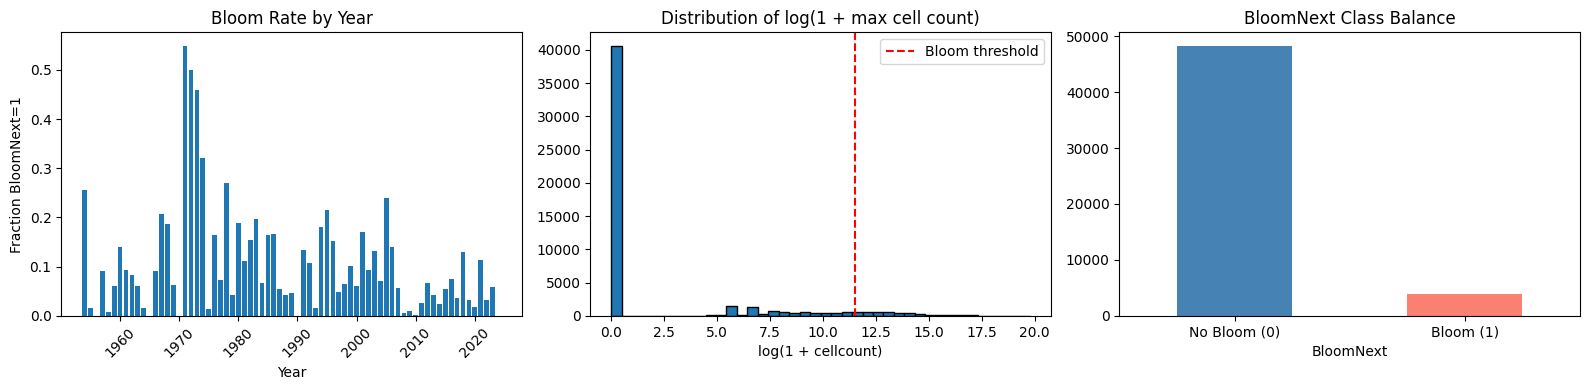

Saved: eda_plots.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# bloom distribution over time
yearly_bloom = feat_df.groupby('year')['BloomNext'].mean()
axes[0].bar(yearly_bloom.index, yearly_bloom.values)
axes[0].set_title('Bloom Rate by Year')
axes[0].set_ylabel('Fraction BloomNext=1')
axes[0].set_xlabel('Year')
axes[0].tick_params(axis='x', rotation=45)

# cell count distribution
axes[1].hist(feat_df['max_log_curr'], bins=40, edgecolor='black')
axes[1].axvline(np.log1p(BLOOM_THRESHOLD), color='red', linestyle='--', label=f'Bloom threshold')
axes[1].set_title('Distribution of log(1 + max cell count)')
axes[1].set_xlabel('log(1 + cellcount)')
axes[1].legend()

# class balance
feat_df['BloomNext'].value_counts().plot.bar(ax=axes[2], color=['steelblue', 'salmon'])
axes[2].set_title('BloomNext Class Balance')
axes[2].set_xticklabels(['No Bloom (0)', 'Bloom (1)'], rotation=0)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_plots.png")

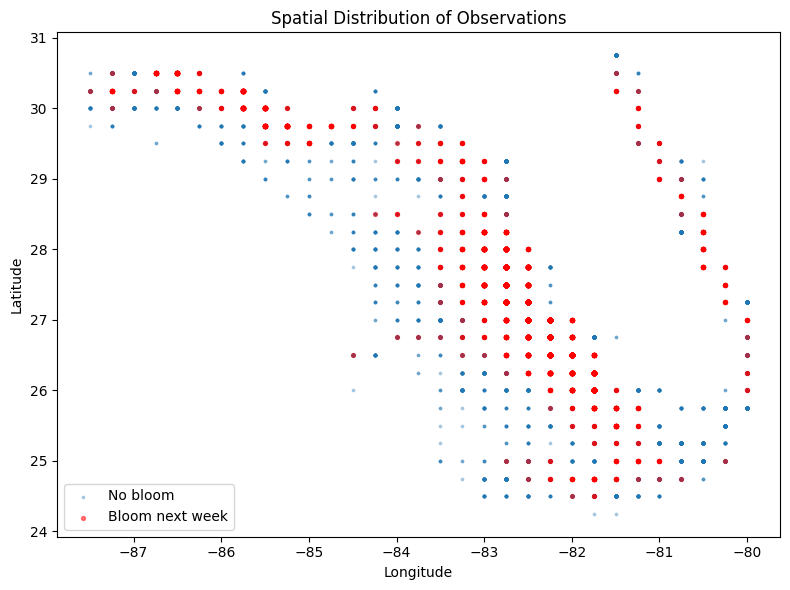

Saved: spatial_plot.png


In [12]:
# spatial plot of bloom observations
fig, ax = plt.subplots(figsize=(8, 6))
bloom_pts = feat_df[feat_df['BloomNext'] == 1]
no_bloom_pts = feat_df[feat_df['BloomNext'] == 0]
ax.scatter(no_bloom_pts['lon_bin'], no_bloom_pts['lat_bin'], s=3, alpha=0.3, label='No bloom')
ax.scatter(bloom_pts['lon_bin'], bloom_pts['lat_bin'], s=8, alpha=0.5, c='red', label='Bloom next week')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Spatial Distribution of Observations')
ax.legend()
plt.tight_layout()
plt.savefig('spatial_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: spatial_plot.png")

## 5. Time-Based Train/Test Split

In [13]:
FEATURE_COLS = [
    'max_log_curr', 'mean_log_curr', 'bloom_curr',
    'max_log_prev1', 'bloom_prev1',
    'max_log_4wk', 'mean_log_4wk', 'bloom_count_4wk',
    'log_diff', 'water_temp'
]

# impute missing water_temp with median
temp_median = feat_df['water_temp'].median()
feat_df['water_temp'] = feat_df['water_temp'].fillna(temp_median)
print(f"Water temp median (used for imputation): {temp_median:.1f} C")

# split: train on all years except the last 2, test on the last 2
all_years = sorted(feat_df['year'].unique())
split_year = all_years[-2]  # last 2 years for test

train_df = feat_df[feat_df['year'] < split_year]
test_df = feat_df[feat_df['year'] >= split_year]

X_train = train_df[FEATURE_COLS].values
y_train = train_df['BloomNext'].values
X_test = test_df[FEATURE_COLS].values
y_test = test_df['BloomNext'].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train years: {sorted(train_df['year'].unique())}")
print(f"Test years: {sorted(test_df['year'].unique())}")
print(f"Train: {len(X_train)} samples, bloom rate = {y_train.mean():.3f}")
print(f"Test:  {len(X_test)} samples, bloom rate = {y_test.mean():.3f}")

Water temp median (used for imputation): 25.4 C
Train years: [np.int64(1954), np.int64(1955), np.int64(1956), np.int64(1957), np.int64(1958), np.int64(1959), np.int64(1960), np.int64(1961), np.int64(1962), np.int64(1963), np.int64(1964), np.int64(1965), np.int64(1966), np.int64(1967), np.int64(1968), np.int64(1969), np.int64(1970), np.int64(1971), np.int64(1972), np.int64(1973), np.int64(1974), np.int64(1975), np.int64(1976), np.int64(1977), np.int64(1978), np.int64(1979), np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2

## 6. Cross-Validation and Model Training

We use 5-fold stratified cross-validation on the training set for model selection,
then evaluate the chosen models on the held-out test years.

In [14]:
# models to compare (proposal: logistic regression, SVMs, decision trees, gradient boosting)
# SVM kernels from class: linear, polynomial (kernel trick), Gaussian/RBF
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, class_weight='balanced'),
    'SVM (Linear)': SVC(kernel='linear', class_weight='balanced', probability=True, C=1.0),
    'SVM (RBF)': SVC(kernel='rbf', class_weight='balanced', probability=True, C=1.0),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1, subsample=0.8
    )
}

# 5-fold stratified CV on training set for model selection
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pr_auc_scorer = 'average_precision'

# SVM is O(n^2+) so we subsample for CV only (train on full set later)
SVM_CV_SUBSAMPLE = 5000
sub_idx = np.random.choice(len(X_train_s), size=min(SVM_CV_SUBSAMPLE, len(X_train_s)), replace=False)
X_train_sub = X_train_s[sub_idx]
y_train_sub = y_train[sub_idx]

print('5-Fold Cross-Validation on Training Set (PR-AUC)')
print('=' * 55)
cv_results = {}
for name, model in models.items():
    if 'SVM' in name:
        scores = cross_val_score(model, X_train_sub, y_train_sub, cv=cv, scoring=pr_auc_scorer)
        print(f'{name:25s}  mean={scores.mean():.4f}  std={scores.std():.4f}  (subsampled to {SVM_CV_SUBSAMPLE})')
    else:
        scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring=pr_auc_scorer)
        print(f'{name:25s}  mean={scores.mean():.4f}  std={scores.std():.4f}')
    cv_results[name] = scores

5-Fold Cross-Validation on Training Set (PR-AUC)
Logistic Regression        mean=0.5332  std=0.0146
Decision Tree              mean=0.4899  std=0.0124
SVM (Linear)               mean=0.5261  std=0.0524  (subsampled to 5000)
SVM (RBF)                  mean=0.3348  std=0.0207  (subsampled to 5000)
Gradient Boosting          mean=0.5339  std=0.0111


In [15]:
# train on full training set, evaluate on test set
# report PR-AUC, F1, MAE, RMSE (as proposed)
# SVM trained on subsample due to O(n^2+) complexity
SVM_TRAIN_SUBSAMPLE = 10000
sub_train_idx = np.random.choice(len(X_train_s), size=min(SVM_TRAIN_SUBSAMPLE, len(X_train_s)), replace=False)
results = {}

print('\nTest Set Evaluation (trained on full training set)')
print('=' * 70)
for name, model in models.items():
    if 'SVM' in name:
        model.fit(X_train_s[sub_train_idx], y_train[sub_train_idx])
        print(f'  (SVM trained on {SVM_TRAIN_SUBSAMPLE} subsample)')
    else:
        model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]

    pr_auc = average_precision_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_prob)
    rmse = np.sqrt(mean_squared_error(y_test, y_prob))

    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'pr_auc': pr_auc, 'f1': f1, 'mae': mae, 'rmse': rmse
    }

    print(f'\n{name}')
    print(f'  PR-AUC={pr_auc:.4f}  F1={f1:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}')
    print(classification_report(y_test, y_pred, target_names=['No Bloom', 'Bloom']))


Test Set Evaluation (trained on full training set)

Logistic Regression
  PR-AUC=0.4726  F1=0.4010  MAE=0.2305  RMSE=0.3247
              precision    recall  f1-score   support

    No Bloom       0.99      0.86      0.92      1609
       Bloom       0.26      0.91      0.40        87

    accuracy                           0.86      1696
   macro avg       0.63      0.88      0.66      1696
weighted avg       0.96      0.86      0.89      1696


Decision Tree
  PR-AUC=0.4757  F1=0.3929  MAE=0.2221  RMSE=0.3269
              precision    recall  f1-score   support

    No Bloom       0.99      0.86      0.92      1609
       Bloom       0.25      0.90      0.39        87

    accuracy                           0.86      1696
   macro avg       0.62      0.88      0.66      1696
weighted avg       0.96      0.86      0.89      1696

  (SVM trained on 10000 subsample)

SVM (Linear)
  PR-AUC=0.4929  F1=0.3538  MAE=0.0810  RMSE=0.1864
              precision    recall  f1-score   support

## 7. Comparison Plots

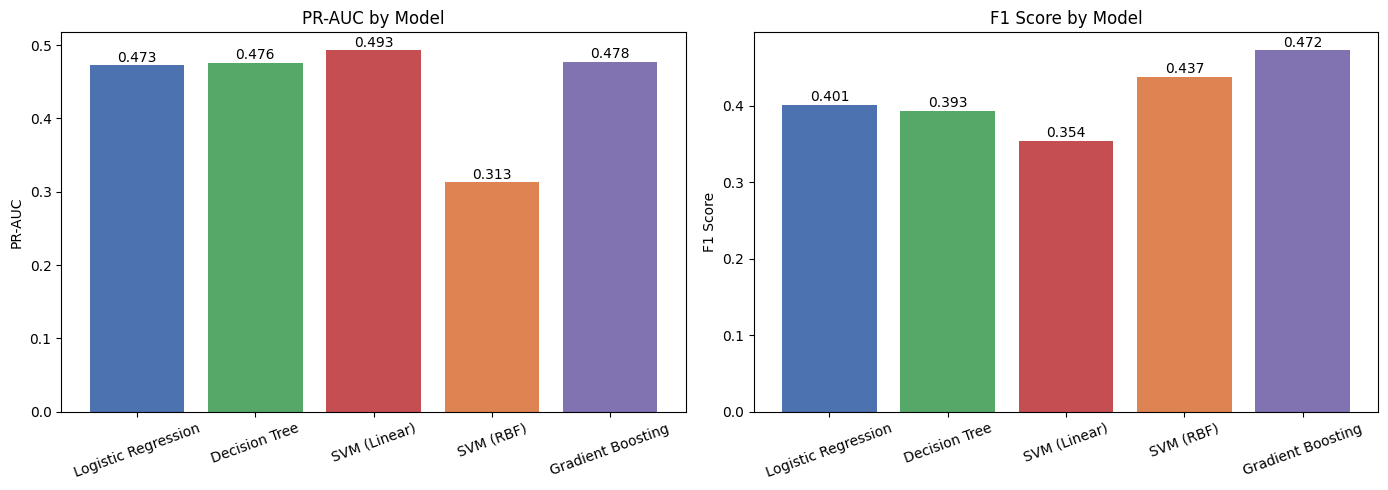

Saved: model_comparison.png


In [16]:
# PR-AUC comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = list(results.keys())
pr_aucs = [results[n]['pr_auc'] for n in names]
f1s = [results[n]['f1'] for n in names]

colors = ['#4c72b0', '#55a868', '#c44e52', '#dd8452', '#8172b2']
axes[0].bar(names, pr_aucs, color=colors)
axes[0].set_ylabel('PR-AUC')
axes[0].set_title('PR-AUC by Model')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(pr_aucs):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

axes[1].bar(names, f1s, color=colors)
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score by Model')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(f1s):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

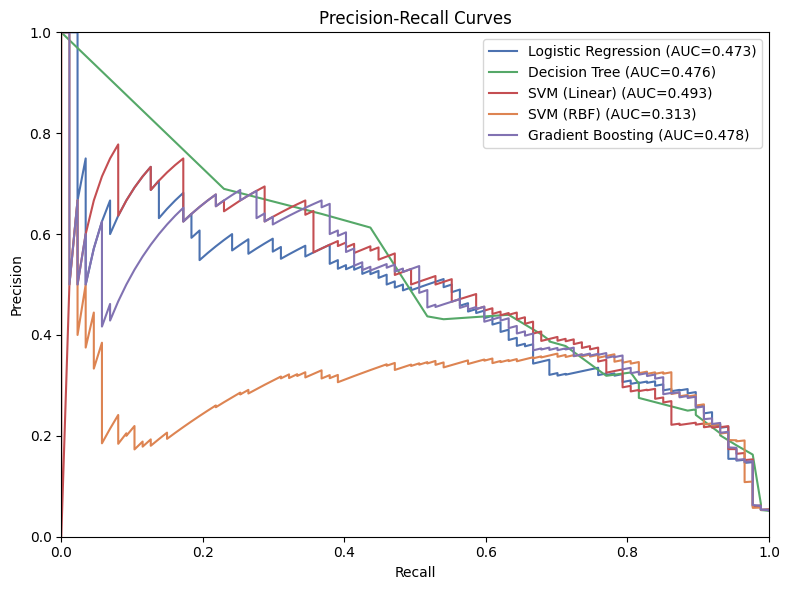

Saved: pr_curves.png


In [17]:
# precision-recall curves
fig, ax = plt.subplots(figsize=(8, 6))

for i, name in enumerate(names):
    prec, rec, _ = precision_recall_curve(y_test, results[name]['y_prob'])
    ax.plot(rec, prec, label=f"{name} (AUC={results[name]['pr_auc']:.3f})", color=colors[i])

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pr_curves.png")

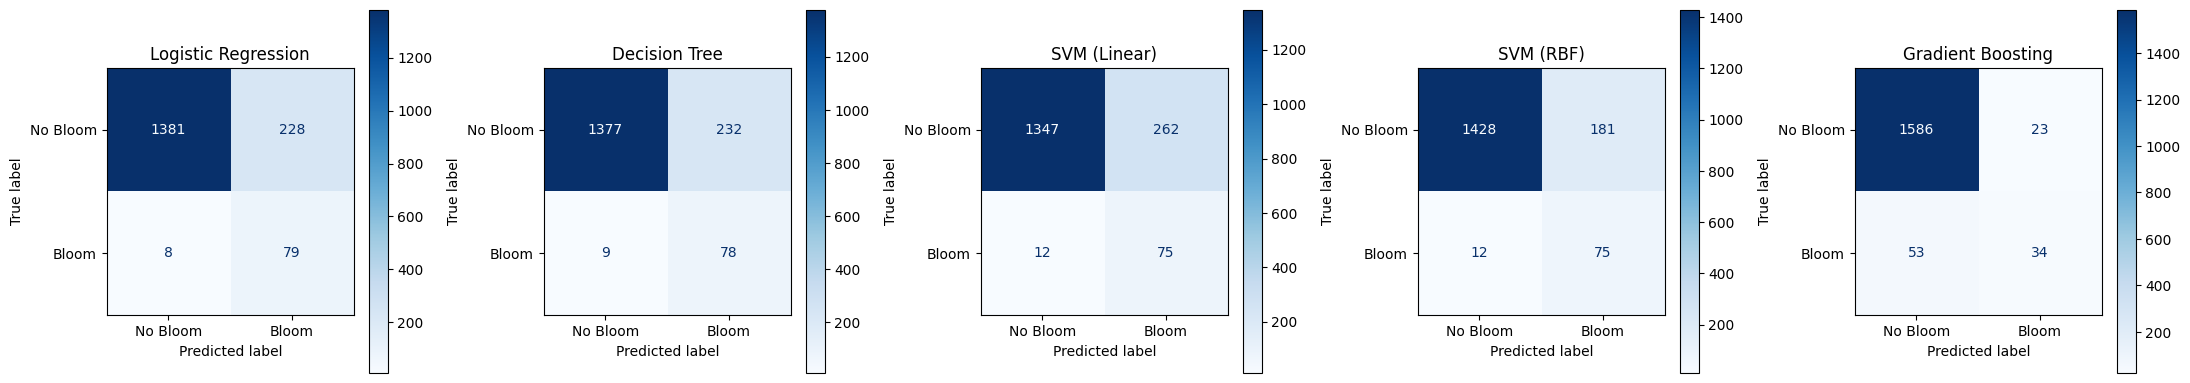

Saved: confusion_matrices.png


In [18]:
# confusion matrices
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for i, name in enumerate(names):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['No Bloom', 'Bloom']).plot(ax=axes[i], cmap='Blues')
    axes[i].set_title(name)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

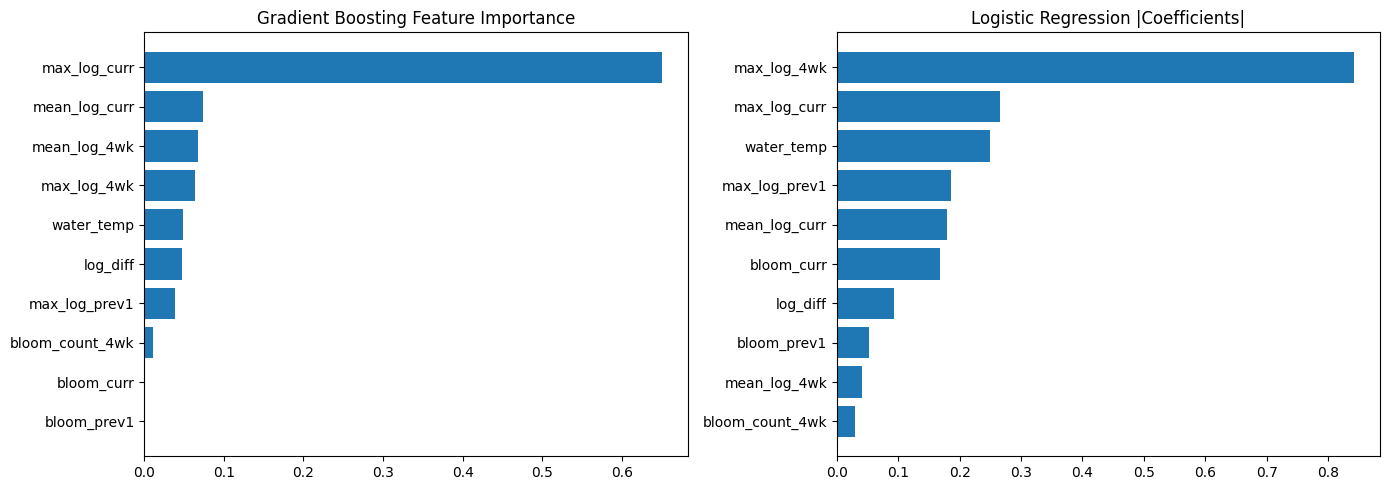

Saved: feature_importance.png


In [19]:
# feature importances (from gradient boosting and logistic regression)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GB feature importance
gb_imp = results['Gradient Boosting']['model'].feature_importances_
idx = np.argsort(gb_imp)
axes[0].barh(np.array(FEATURE_COLS)[idx], gb_imp[idx])
axes[0].set_title('Gradient Boosting Feature Importance')

# LR coefficients
lr_coef = np.abs(results['Logistic Regression']['model'].coef_[0])
idx2 = np.argsort(lr_coef)
axes[1].barh(np.array(FEATURE_COLS)[idx2], lr_coef[idx2])
axes[1].set_title('Logistic Regression |Coefficients|')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: feature_importance.png")

## 8. Summary Table

In [20]:
summary = pd.DataFrame({
    'Model': names,
    'CV PR-AUC': [cv_results[n].mean() for n in names],
    'Test PR-AUC': [results[n]['pr_auc'] for n in names],
    'F1': [results[n]['f1'] for n in names],
    'MAE': [results[n]['mae'] for n in names],
    'RMSE': [results[n]['rmse'] for n in names],
    'Precision': [
        confusion_matrix(y_test, results[n]['y_pred'])[1,1] /
        max(1, confusion_matrix(y_test, results[n]['y_pred'])[:, 1].sum())
        for n in names
    ],
    'Recall': [
        confusion_matrix(y_test, results[n]['y_pred'])[1,1] /
        max(1, confusion_matrix(y_test, results[n]['y_pred'])[1, :].sum())
        for n in names
    ]
}).round(4)

print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)
print(summary.to_string(index=False))
print(f"\nDataset: {len(feat_df)} samples, {feat_df['BloomNext'].mean():.1%} positive")
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train years: {sorted(train_df['year'].unique())}")
print(f"Test years: {sorted(test_df['year'].unique())}")
print(f"Features: {FEATURE_COLS}")
print(f"Bloom threshold: {BLOOM_THRESHOLD} cells/L")
print(f"Grid resolution: {GRID_SIZE} degrees")


RESULTS SUMMARY
              Model  CV PR-AUC  Test PR-AUC     F1    MAE   RMSE  Precision  Recall
Logistic Regression     0.5332       0.4726 0.4010 0.2305 0.3247     0.2573  0.9080
      Decision Tree     0.4899       0.4757 0.3929 0.2221 0.3269     0.2516  0.8966
       SVM (Linear)     0.5261       0.4929 0.3538 0.0810 0.1864     0.2226  0.8621
          SVM (RBF)     0.3348       0.3126 0.4373 0.0855 0.1956     0.2930  0.8621
  Gradient Boosting     0.5339       0.4776 0.4722 0.0746 0.1860     0.5965  0.3908

Dataset: 52090 samples, 7.3% positive
Train: 50394 | Test: 1696
Train years: [np.int64(1954), np.int64(1955), np.int64(1956), np.int64(1957), np.int64(1958), np.int64(1959), np.int64(1960), np.int64(1961), np.int64(1962), np.int64(1963), np.int64(1964), np.int64(1965), np.int64(1966), np.int64(1967), np.int64(1968), np.int64(1969), np.int64(1970), np.int64(1971), np.int64(1972), np.int64(1973), np.int64(1974), np.int64(1975), np.int64(1976), np.int64(1977), np.int64(1978), 

## 9. Print Numbers for Update Report
Run this cell and copy the output for the project update.

In [21]:
best_name = max(results, key=lambda n: results[n]['pr_auc'])
best = results[best_name]

print("=" * 60)
print("COPY THESE NUMBERS FOR THE PROJECT UPDATE")
print("=" * 60)
print(f"Total observations (raw): {len(raw)}")
print(f"Total observations (cleaned): {len(df)}")
print(f"Date range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
print(f"Weekly aggregated samples: {len(weekly)}")
print(f"Feature dataset size: {len(feat_df)}")
print(f"Unique grid cells: {df['grid_cell'].nunique()}")
print(f"BloomNext positive rate: {feat_df['BloomNext'].mean():.1%}")
print(f"Number of features: {len(FEATURE_COLS)}")
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

print(f"\nBest model (test PR-AUC): {best_name}")
print(f"Best PR-AUC: {best['pr_auc']:.4f}")
print(f"Best F1: {best['f1']:.4f}")

print(f"\nAll results (CV mean | Test PR-AUC | F1 | MAE | RMSE):")
for n in names:
    r = results[n]
    cv_mean = cv_results[n].mean()
    print(f"  {n}: CV={cv_mean:.4f} | PR-AUC={r['pr_auc']:.4f} | F1={r['f1']:.4f} | MAE={r['mae']:.4f} | RMSE={r['rmse']:.4f}")

COPY THESE NUMBERS FOR THE PROJECT UPDATE
Total observations (raw): 211834
Total observations (cleaned): 205168
Date range: 1953-08-19 to 2024-03-25
Weekly aggregated samples: 53998
Feature dataset size: 52090
Unique grid cells: 498
BloomNext positive rate: 7.3%
Number of features: 10
Train size: 50394, Test size: 1696

Best model (test PR-AUC): SVM (Linear)
Best PR-AUC: 0.4929
Best F1: 0.3538

All results (CV mean | Test PR-AUC | F1 | MAE | RMSE):
  Logistic Regression: CV=0.5332 | PR-AUC=0.4726 | F1=0.4010 | MAE=0.2305 | RMSE=0.3247
  Decision Tree: CV=0.4899 | PR-AUC=0.4757 | F1=0.3929 | MAE=0.2221 | RMSE=0.3269
  SVM (Linear): CV=0.5261 | PR-AUC=0.4929 | F1=0.3538 | MAE=0.0810 | RMSE=0.1864
  SVM (RBF): CV=0.3348 | PR-AUC=0.3126 | F1=0.4373 | MAE=0.0855 | RMSE=0.1956
  Gradient Boosting: CV=0.5339 | PR-AUC=0.4776 | F1=0.4722 | MAE=0.0746 | RMSE=0.1860
